In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os

from _Prettyplt import PrettyPlot as pp
from _Geometry_methods import Geometry_helper as gh
pp.makePretty(0.8)

In [2]:
# Load materials from XML
#materials = openmc.Materials.from_xml("materials-finish.xml")

#Using fond materials 
#materials = results.export_to_materials(1)
# Collect all nuclides present
nuclides = []

materials = openmc.Materials.from_xml("materials.xml")
fuel_name = "Fuel_C"
fuel = gh.get_material_by_name(fuel_name,materials)

for nuclide, amount,_ in fuel.nuclides:
    nuclides.append([nuclide,amount])

print(nuclides)

[['Li6', 1.948861945819785e-05], ['Li7', 0.2633402337885551], ['F19', 0.594637869740933], ['Be9', 0.11836574203564754], ['Zr90', 0.010427940800914495], ['Zr91', 0.002274081550753365], ['Zr92', 0.0034759802669714988], ['Zr94', 0.003522596911951292], ['Zr96', 0.0005675069823626938], ['U234', 9.180444797269919e-06], ['U235', 0.0012066476488254612], ['U236', 9.102479914025151e-06], ['U238', 0.002143628728916089]]


In [3]:
import openmc.data
import re
decay = openmc.data.Decay.from_endf("../endf-b-vii.1/decay/dec-094_Pu_239.endf")

def make_AZ_Str(AZ):
    #Makes sure that number has 3 digits as in endf files and turns the numbers into strings
    if AZ < 10:
        AZstr = f"00{AZ}"
    elif AZ < 100:
        AZstr = f"0{AZ}"
    else:
        AZstr = f"{AZ}"
    return AZstr
def get_decay_data(nuclide_name):
    #Isolating the atomic symbol
    Z, A, m =openmc.data.zam(nuclide_name)
    match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
    m1=0
    if match == None:
        match = re.match(r"([A-Za-z]+)",nuclide_name)
        symbol =match.groups()[0]
    else:
        symbol, _,_ ,m1 =match.groups()
    
    Z = make_AZ_Str(Z)
    A = make_AZ_Str(A)

    #Getting decay data from ground state or excited (m1)
    try:
        if m1 != 0:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
        else:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")
    except Keyerror:
        print("ERROR",Keyerror)
        dec = None
    return dec

def has_alpha_decay(nuclide):
    #Checking if atoms have alpha decay
    nuclide_name=nuclide[0]
    dec = get_decay_data(nuclide_name)
    for mode in dec.modes:
        if mode.modes[0] == "alpha":
            return True
    return False   


#print(has_alpha_decay(nuclides[3]))        
alpha_nuclides = [nuc for nuc in nuclides if has_alpha_decay(nuc)]

#print(alpha_nuclides)


In [4]:
def alpha_decay_values_from_material(material,material_volume,show_discarded=False):
    '''
    Method for finding aplha source for a given material. Using volume of the openmc.Material
    Parameters
    ----------
    material: openmc.Material
        material to analyze
    geom: openmc.Geometry
        geometry for the given problem used to calculated the amount of atoms
    cell_name: str
        name of the openmc.Geometry cell the material is in
    show_discarded: boolean
        enables the printing of every material discarded do to no alha emission
    
    Returns
    -------
    result:arrays[array[str],array[flaot],array[float],array[float],array[float]]
        [nuclide_name,activities,energies,energy_sted_devs, mass in kg]
    material_mass: float
        total mass of the material
    None
    '''
    result = []
    material_mass = 0
    material_cell = openmc.Cell(1,'fuel')
    material_cell.fill = material

    #Getting the volume from the material
    try:
        material_cell.volume = material_volume
        #print('material.volume: ',material.volume)
    except Exception as e:
        print(f'Error no material volume defined {e}')
    
    
    for nuclide_name, nuclide_amount_percent,_ in material.nuclides:
        #print(nuclide_name, nuclide_amount_percent)
        Z, A, m =openmc.data.zam(nuclide_name)
        #print(f'number of {nuclide_name} atoms {material_cell.atoms[nuclide_name]}')
        nuclide_amount = material_cell.atoms[nuclide_name]
        nuclide_mass = openmc.data.atomic_mass(nuclide_name)
        total_isotope_mass = nuclide_mass*nuclide_amount
        #print('nuclide mass', nuclide_mass, 'total mass ',total_isotope_mass*1.6605402e-27)
        material_mass += total_isotope_mass
        
        dec = get_decay_data(nuclide_name)

        #Seeing if decay constant is possible to return
        try:
            decay_constant = dec.decay_constant.nominal_value #log(2)/half_life
        except ValueError as e:
            if show_discarded:
                print(f"Skipping {dec.nuclide['name']} amount: {nuclide_amount:.3g}: {e}")
                decay_constant = 0
        
        #Finding the spectra and calculating the activity
        if len(dec.spectra)!=0 and has_alpha_decay([nuclide_name]):
            alpha_data=dec.spectra['alpha']
            energies = [float(item['energy'].nominal_value) for item in alpha_data['discrete']] #can be continuous or discrete
            energy_std_devs = [float(item['energy'].std_dev) for item in alpha_data['discrete']]
            intensities  = [float(item['intensity'].nominal_value) for item in alpha_data['discrete']]

            #This is total activity
            activities = [decay_constant*nuclide_amount*intensity for intensity in intensities] #Calculation of activities
            result.append([nuclide_name,activities,energies,energy_std_devs, total_isotope_mass*1.6605402e-27])
        else:
            if show_discarded:
                activity=decay_constant*nuclide_amount
                print(dec.nuclide['name'],f"activity: {activity:.3g} has no alpha spectra")

    material_mass = material_mass*1.6605402e-27
    #print(f'total mass of {cell_name} filled with {material.name} is {material_mass:.3g} kg which gives a density of {material_mass*1000/material_cell.volume:.3g} g/cm^3')
    return result, material_mass
fuel_volume = 707921
print(fuel.name,'volume: ',fuel_volume)

alpha_spectra_data1,total_mass = alpha_decay_values_from_material(fuel,fuel_volume)



Fuel_C volume:  707921


name	activity	energy_std_dev	energy
U234       3.32e+03         1500.0	4.11e+06
U234       1.23e+04         1500.0	4.15e+06
U234        1.9e+04         1500.0	4.28e+06
U234        9.5e+07         1500.0	4.6e+06
U234       1.35e+10         1400.0	4.72e+06
U234       3.39e+10         1400.0	4.77e+06
U235       2.18e+04       688.0851	3.98e+06
U235       4.35e+05       688.0851	4.08e+06
U235       1.96e+07         5000.0	4.15e+06
U235       1.24e+08         1900.0	4.21e+06
U235       1.96e+07         6000.0	4.22e+06
U235        3.7e+05       688.0851	4.22e+06
U235       8.71e+06         5000.0	4.27e+06
U235       7.18e+05       688.0851	4.28e+06
U235       2.18e+06       688.0851	4.29e+06
U235       1.96e+05       429500.0	4.3e+06
U235       9.58e+07       688.0851	4.33e+06
U235       4.57e+06       688.0851	4.33e+06
U235       5.22e+06       688.0851	4.36e+06
U235        3.7e+08         2000.0	4.37e+06
U235       3.37e+06       688.0851	4.38e+06
U235        1.2e+09         1300.0	4.4e+06

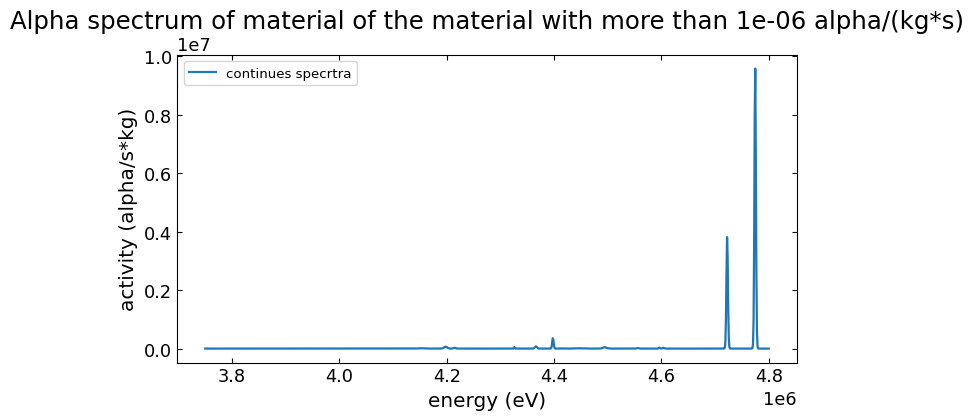

In [13]:
def gaussian(A,a,b,x):
    fx=A/(a*np.sqrt(2*np.pi))*np.exp(-(x-b)**2/(2*a**2))
    np.array(fx)
    return fx


def plot_material_energy_spectra(ax,alpha_spectra_data,total_mass,plot_threshold=1e-5,show_discarded=False):
    ax.set_title(f"Alpha spectrum of material of the material with more than {plot_threshold} alpha/(kg*s)")
    ax.semilogy()
    ax.set_xlabel("energy (eV)")
    ax.set_ylabel("activity (alpha/s*kg)")
    for name, activities, energies,energy_devs,_  in alpha_spectra_data:
        activities_pr_kg = activities#/total_mass
        if sum(activities_pr_kg) > plot_threshold:
            line, =ax.plot(energies, activities_pr_kg, "_", label=name,ms=10)
            ax.vlines(energies,[0]*len(energies),activities_pr_kg,line.get_color(),alpha=0.3)
        elif show_discarded:
            print(f'{name} with a total activity of {sum(activities_pr_kg):.2g} alpha/(kg*s) is not plotted')
    ax.legend()
def plot_material_energy_spectra_gaussian(ax,alpha_spectra_data,total_mass,plot_threshold=1e-5,show_discarded=False):
    ax.set_title(f"Alpha spectrum of material of the material with more than {plot_threshold} alpha/(kg*s)")
    #ax.semilogy()
    ax.set_xlabel("energy (eV)")
    ax.set_ylabel("activity (alpha/s*kg)")
    x = np.linspace(3.75e6,4.8e6,1000)
    energy_spectra = np.zeros(len(x), dtype=float)
    E_as = []
    print('name\tactivity\tenergy_std_dev\tenergy')
    for name, activities, energies,energy_devs,_  in alpha_spectra_data:
        for activity,energy,energy_std_dev in zip(activities, energies,energy_devs):
            print(f'{name}{activity:>15,.3g}{energy_std_dev:>15}\t{energy:.3g}')
            E_as.append(energy)
            energy_spectra += gaussian(activity,energy_std_dev,energy,x)
    ax.plot(x,energy_spectra,label='continues specrtra')
    ax.legend()
    print(E_as)
    return energy_spectra

def energy_spectra_gaussian(Spectra_data,min_lim = 3.5e6,max_lim = 5e6,number_of_points = 10000):
    x = np.linspace(min_lim,max_lim,int(number_of_points))
    energy_spectra = np.zeros(len(x), dtype=float)
    print('name\tactivity\tenergy_std_dev\tenergy')
    for name, activities, energies,energy_devs,_  in alpha_spectra_data:
        for activity,energy,energy_std_dev in zip(activities, energies,energy_devs):
            print(f'{name}{activity:>15,.3g}{energy_std_dev:>15}\t{energy:.3g}')
            energy_spectra += gaussian(activity,energy_std_dev,energy,x)
    return energy_spectra

fig,ax = plt.subplots()    
#plot_material_energy_spectra(ax,alpha_spectra_data1,total_mass,plot_threshold=1e-6)
energy_spectra = plot_material_energy_spectra_gaussian(ax,alpha_spectra_data1,total_mass,plot_threshold=1e-6)

Fuel_C: total volume: 707921
total_mass 1.62e+03
U234 mass in kg 0.2062339039
U235 mass in kg 27.22287532
U236 mass in kg 0.2062339039
U238 mass in kg 48.98055218


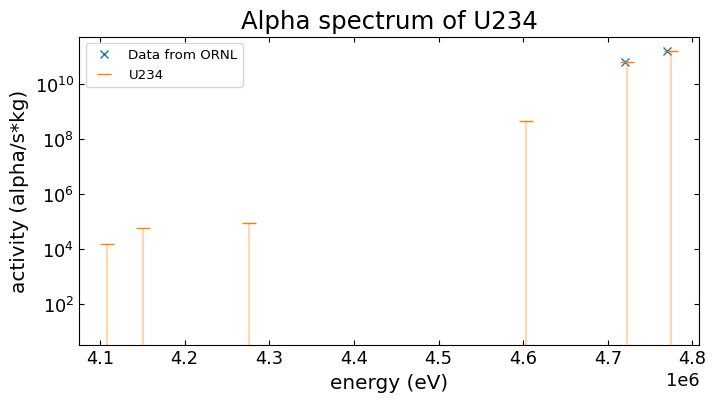

In [6]:
energy_ORNL_dict={
    'U234':[4.77e6,4.72e6],
    'U235':[4.58e6,4.47e6,4.40e6,4.20e6],
    'U236':[4.5e6,4.45e6],
    'U238':[4.19e6,4.15e6]
}
alpha_source_ORNL_dict={
    'U234':[1.64e11,0.64e11],
    'U235':[0.79e7,0.24e7,6.56e7,0.32e7],
    'U236':[1.72e9,0.63e9],
    'U238':[0.95e6,0.28e6]
}
alpha_in_fuel_ORNL_dict={
    'Fuel_A':{ 'U234':[4.74e10,1.85e10],
    'U235':[2.13e8,0.65e8,17.7e8,0.86e8],
    'U236':[5.01e8,1.83e8],
    'U238':[1.40e6,0.41e6]},
    'Fuel_B':{ 'U234':[2.9e10,1.13e10],
    'U235':[1.30e8,0.40e8,10.8e8,0.53e8],
    'U236':[3.06e8,1.12e8],
    'U238':[0.86e6,0.25e6]},
    'Fuel_C':{ 'U234':[3.71e10,1.45e10],
    'U235':[2.09e8,0.63e8,17.3e8,0.85e8],
    'U236':[3.92e8,1.44e8],
    'U238':[0.45e8,0.13e8]},
}

def plot_isotope_in_material(ax,alpha_spectra_data,isotope,total_mass):
    print(f'total_mass {total_mass:.3g}')
    for name, activities, energies,_,mass  in alpha_spectra_data:
        activities_pr_kg = activities/total_mass
        
        print(f'{name} mass in kg {mass:.10g}')
        mass_percent = mass/total_mass
        if isotope==name:
            line, =ax.plot(energies, activities_pr_kg/mass_percent, "_", label=name,ms=10)
            ax.vlines(energies,[0]*len(energies),activities_pr_kg/mass_percent,line.get_color(),alpha=0.3)

fig1,ax1 = plt.subplots()

isotope_name="U234"

ax1.set_title(f"Alpha spectrum of {isotope_name}")
ax1.semilogy()
ax1.set_xlabel("energy (eV)")
ax1.set_ylabel("activity (alpha/s*kg)")

ax1.plot(energy_ORNL_dict[isotope_name],alpha_source_ORNL_dict[isotope_name],"x",label="Data from ORNL")
print(f'{fuel.name}: total volume: {fuel_volume}')
plot_isotope_in_material(ax1,alpha_spectra_data1,isotope_name,total_mass)
ax1.legend()

In [7]:
def print_deacy_data(nuclide_name):
    dec = get_decay_data(nuclide_name)
    mass = openmc.data.atomic_mass(nuclide_name)/6.022136651E+26 #Convertion from unit to kg
    print(dec.modes)
    print('Halflife (s)\t',dec.half_life)
    print(f'Halflife (y)\t{dec.half_life.nominal_value/(3600*24*365.25):.3g}')
    print('Decay_constant\t',dec.decay_constant)
    #print('Calculated decay constant (s) ',np.log(2)/dec.half_life.nominal_value)
    
    print('\nEnergy \t\t\tIntensity\t\t decay')
    total = 0
    for item in dec.spectra['alpha']['discrete']:
        print(item['energy'],'\t',item['intensity'],'\t',item['intensity']*dec.decay_constant/mass)
        total+=item['intensity'].nominal_value
    print(f'Total intensity {total:.3g}')
print_deacy_data('U234')

#print(1/6.022136651E+26)

[<DecayMode: (sf), U234 -> U234, (1.70+/-0.10)e-11>, <DecayMode: (alpha), U234 -> Th230, 1.0+/-0>]
Halflife (s)	 (7.747+/-0.019)e+12
Halflife (y)	2.45e+05
Decay_constant	 (8.947+/-0.022)e-14

Energy 			Intensity		 decay
(4.1086+/-0.0015)e+06 	 (7.0+/-0.7)e-08 	 (1.61+/-0.16)e+04
(4.1506+/-0.0015)e+06 	 (2.6+/-0.9)e-07 	 (6.0+/-2.1)e+04
(4.2761+/-0.0015)e+06 	 (4.0+/-1.0)e-07 	 (9.2+/-2.3)e+04
(4.6035+/-0.0015)e+06 	 0.00200+/-0.00010 	 (4.60+/-0.23)e+08
(4.7224+/-0.0014)e+06 	 0.2842+/-0.0009 	 (6.543+/-0.026)e+10
(4.7746+/-0.0014)e+06 	 0.7138+/-0.0016 	 (1.643+/-0.005)e+11
Total intensity 1


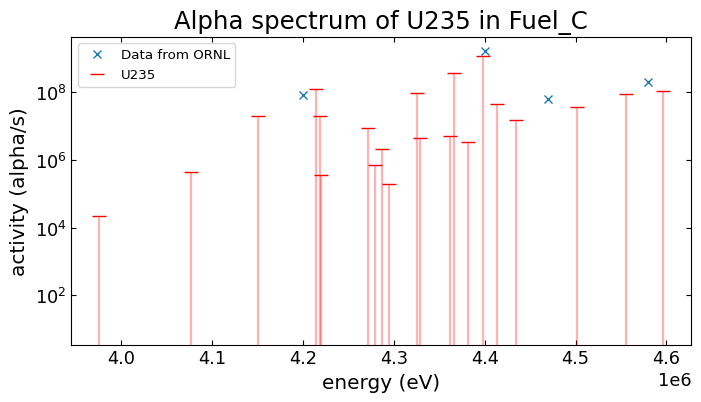

In [8]:
fig2,ax2 = plt.subplots()
ax2.semilogy()
ax2.set_xlabel("energy (eV)")
ax2.set_ylabel("activity (alpha/s)")

def plot_isotope_in_material_ORNL_comp(ax,alpha_spectra_data,isotope,color):
    for name, activities, energies,_,mass  in alpha_spectra_data:
        if isotope==name:
            line, =ax.plot(energies, activities, "_", label=name,ms=10,color=color)
            ax.vlines(energies,[0]*len(energies),activities,line.get_color(),alpha=0.3)



isotope_name="U235"
ax2.set_title(f"Alpha spectrum of {isotope_name} in {fuel_name}")

ax2.plot(energy_ORNL_dict[isotope_name],alpha_in_fuel_ORNL_dict[fuel_name][isotope_name],"x",label="Data from ORNL")
plot_isotope_in_material_ORNL_comp(ax2,alpha_spectra_data1,isotope_name,color='red')

ax2.legend()

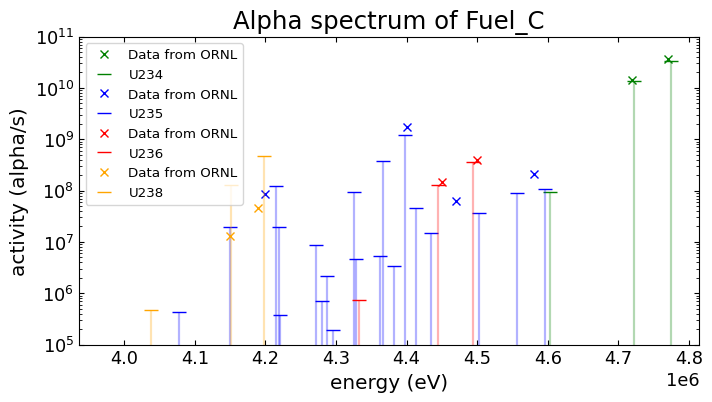

In [9]:
fig3,ax3 = plt.subplots()
ax3.semilogy()
ax3.set_xlabel("energy (eV)")
ax3.set_ylabel("activity (alpha/s)")
ax3.set_title(f"Alpha spectrum of {fuel_name}")
for isotope_name,color in zip(['U234','U235','U236','U238'],['green','blue','red','orange']):
    ax3.plot(energy_ORNL_dict[isotope_name],alpha_in_fuel_ORNL_dict[fuel_name][isotope_name],"x",label="Data from ORNL",color=color)
    plot_isotope_in_material_ORNL_comp(ax3,alpha_spectra_data1,isotope_name,color=color)
ax3.legend()
ax3.set_ylim(1e5,1e11)
pp.savefig(f"Alpha spectrum of {fuel_name}")

{4580000.0: [4556000.0, 4596400.0], 4470000.0: [4435000.0, 4502000.0], 4400000.0: [4366100.0, 4381431.0, 4397800.0, 4414000.0, 4435000.0], 4200000.0: [4214700.0, 4219000.0, 4219928.0]}
{4580000.0: [np.float64(91423500.46081614), np.float64(108837500.54859065)], 4470000.0: [np.float64(15237250.07680269), np.float64(37004750.18652082)], 4400000.0: [np.float64(370047501.8652082), np.float64(3373962.5170063097), np.float64(1197212506.034497), np.float64(45711750.23040807), np.float64(15237250.07680269)], 4200000.0: [np.float64(124074750.62539333), np.float64(19590750.098746315), np.float64(370047.5018652082)]}
[np.float64(200261001.0094068), np.float64(52242000.263323516), np.float64(1631582970.7239223), np.float64(144035548.22600484)]


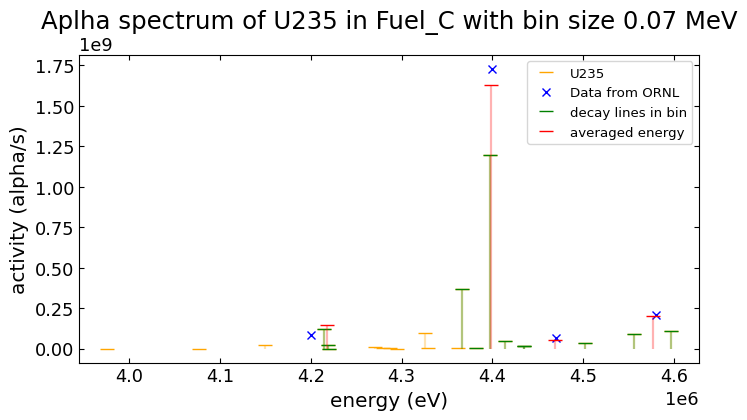

In [10]:
isotope_name='U235'
energy_dev = 0.35e5
fig4,ax4 = plt.subplots()
ax4.set_xlabel("energy (eV)")
ax4.set_ylabel("activity (alpha/s)")
ax4.set_title(f"Aplha spectrum of {isotope_name} in {fuel_name} with bin size {2*energy_dev*1e-6:.3g} MeV")

relevant_energies_dict = {}
relevant_activities_dict = {}
relevant_energies = []
relevant_activities = []
result_energies = []
result_activities = []


for name, activities, energies,_,mass  in alpha_spectra_data1:
    if isotope_name==name:
        for ORNL_energy in energy_ORNL_dict[isotope_name]:
            for energy,activity in zip(energies,activities,):
                
                if ORNL_energy+energy_dev>=energy>=ORNL_energy-energy_dev:
                    relevant_energies.append(energy)
                    relevant_activities.append(activity)
                    if relevant_energies_dict.get(ORNL_energy) is None:
                        relevant_energies_dict[ORNL_energy]=[energy]
                        relevant_activities_dict[ORNL_energy]=[activity]
                    else:
                        relevant_energies_dict[ORNL_energy].append(energy)
                        relevant_activities_dict[ORNL_energy].append(activity)
            if relevant_energies_dict.get(ORNL_energy) is not None:
                k=relevant_energies_dict[ORNL_energy]
                result_energies.append(sum(k)/len(k))
                result_activities.append(sum(relevant_activities_dict[ORNL_energy]))


print(relevant_energies_dict)
print(relevant_activities_dict)

print(result_activities)

plot_isotope_in_material_ORNL_comp(ax4,alpha_spectra_data1,isotope_name,color='orange')

ax4.plot(energy_ORNL_dict[isotope_name],alpha_in_fuel_ORNL_dict[fuel_name][isotope_name],"x",label="Data from ORNL",color='blue')
line, =ax4.plot(relevant_energies, relevant_activities, "_",ms=10,color='green',label=f"decay lines in bin")
ax4.vlines(relevant_energies,[0]*len(relevant_energies),relevant_activities,line.get_color(),alpha=0.3)

line, =ax4.plot(result_energies, result_activities, "_",ms=10,color='red',label="averaged energy")
ax4.vlines(result_energies,[0]*len(result_energies),result_activities,line.get_color(),alpha=0.3)


ax4.legend()